### **Eksplorasi dan Visualisasi Data pada California Housing Dataset** ###


**Nama**        : Marcella Ariani              
**NIM**         : 20254920003                 
**Mata Kuliah** : Eksplorasi dan Visualisasi Data  

---

### **Deskripsi Dataset California Housing** ###

Dataset California Housing berisi informasi mengenai kondisi perumahan di wilayah California, Amerika Serikat, yang dikumpulkan berdasarkan blok sensus. Data ini digunakan untuk menganalisis faktor-faktor yang memengaruhi nilai median harga rumah.

Dataset terdiri dari beberapa variabel numerik seperti pendapatan penduduk, usia rumah, jumlah ruangan, jumlah kamar tidur, populasi, serta rata-rata penghuni dalam satu rumah. Selain itu, terdapat juga variabel geografis berupa latitude dan longitude yang menunjukkan lokasi wilayah.

Variabel utama dalam dataset ini adalah **MedHouseVal**, yang merepresentasikan nilai median harga rumah dan sering digunakan sebagai variabel target dalam analisis.

Melalui dataset ini, dapat dilakukan berbagai analisis seperti eksplorasi distribusi data, analisis hubungan antar variabel, serta pemodelan regresi untuk memahami faktor-faktor yang memengaruhi harga rumah.


---

### **SOAL 1** ###                              
**a. Jelaskan secara rinci apa yang dimaksud dengan Eksplorasi Data Analysis (EDA)!**            
Menurut John W. Tukey (1977), Exploratory Data Analysis (EDA) adalah pendekatan untuk menganalisis data dengan cara merangkum karakteristik utama data, biasanya dengan menggunakan metode visual.

Dalam praktiknya, EDA meliputi:
- pemeriksaan struktur data  
- analisis distribusi data  
- deteksi outlier  
- identifikasi pola dan hubungan antar variabel  

EDA bertujuan untuk memahami data sebelum dilakukan analisis atau pemodelan lebih lanjut.  


**b. Mengapa penting untuk melakukan EDA sebelum melakukan analisis yang lebih lanjut?**           
Menurut Han, Kamber, dan Pei (2012), EDA membantu memahami kondisi dan karakteristik data sehingga analisis yang dilakukan menjadi lebih akurat dan tepat. Tanpa proses EDA, hasil analisis berpotensi bias atau menyesatkan karena data belum dipahami dengan baik.

**c. Pada California Housing Dataset variabel mana yang kemungkinan bisa dilakukan analisis distribusi data, analisis korelasi, dan analisis regresi?**

| Jenis Analisis | Variabel yang Direkomendasikan | Keterangan |
|----------------|--------------------------------|------------|
| **Distribusi Data** | MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude, MedHouseVal | Semua variabel bersifat numerik sehingga dapat dianalisis distribusinya |
| **Korelasi** | Semua variabel numerik | Fokus pada hubungan MedInc ↔ MedHouseVal (kuat) serta AveRooms ↔ AveBedrms (indikasi multikolinearitas) |
| **Regresi** | **Y:** MedInc <br> **X:** MedHouseVal, HouseAge, AveRooms, AveBedrms | Hindari AveBedrms bersamaan dengan AveRooms, serta perhatikan outlier pada Population dan AveOccup |

**d. Jelaskan kenapa variabel Lattitude dan Longitude tidak dimasukkan pada analisis distribusi data, analisis korelasi, dan analisis regresi!**                       
Variabel Latitude dan Longitude tidak digunakan karena berfungsi sebagai indikator lokasi, bukan variabel yang memiliki hubungan langsung secara kausal dengan variabel ekonomi. Selain itu, pengaruh lokasi biasanya bersifat spasial dan non-linear, sehingga memerlukan metode khusus.

---

### **SOAL 2** ###                           
Lakukan visualisasi data numerik dari dataset California Housing. Gunakan histogram untuk menampilkan distribusi dari variabel-variabel numerik, dan jelaskan apa yang bisa diambil dari visualisasi tersebut.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#### **Visualisasi Histogram**

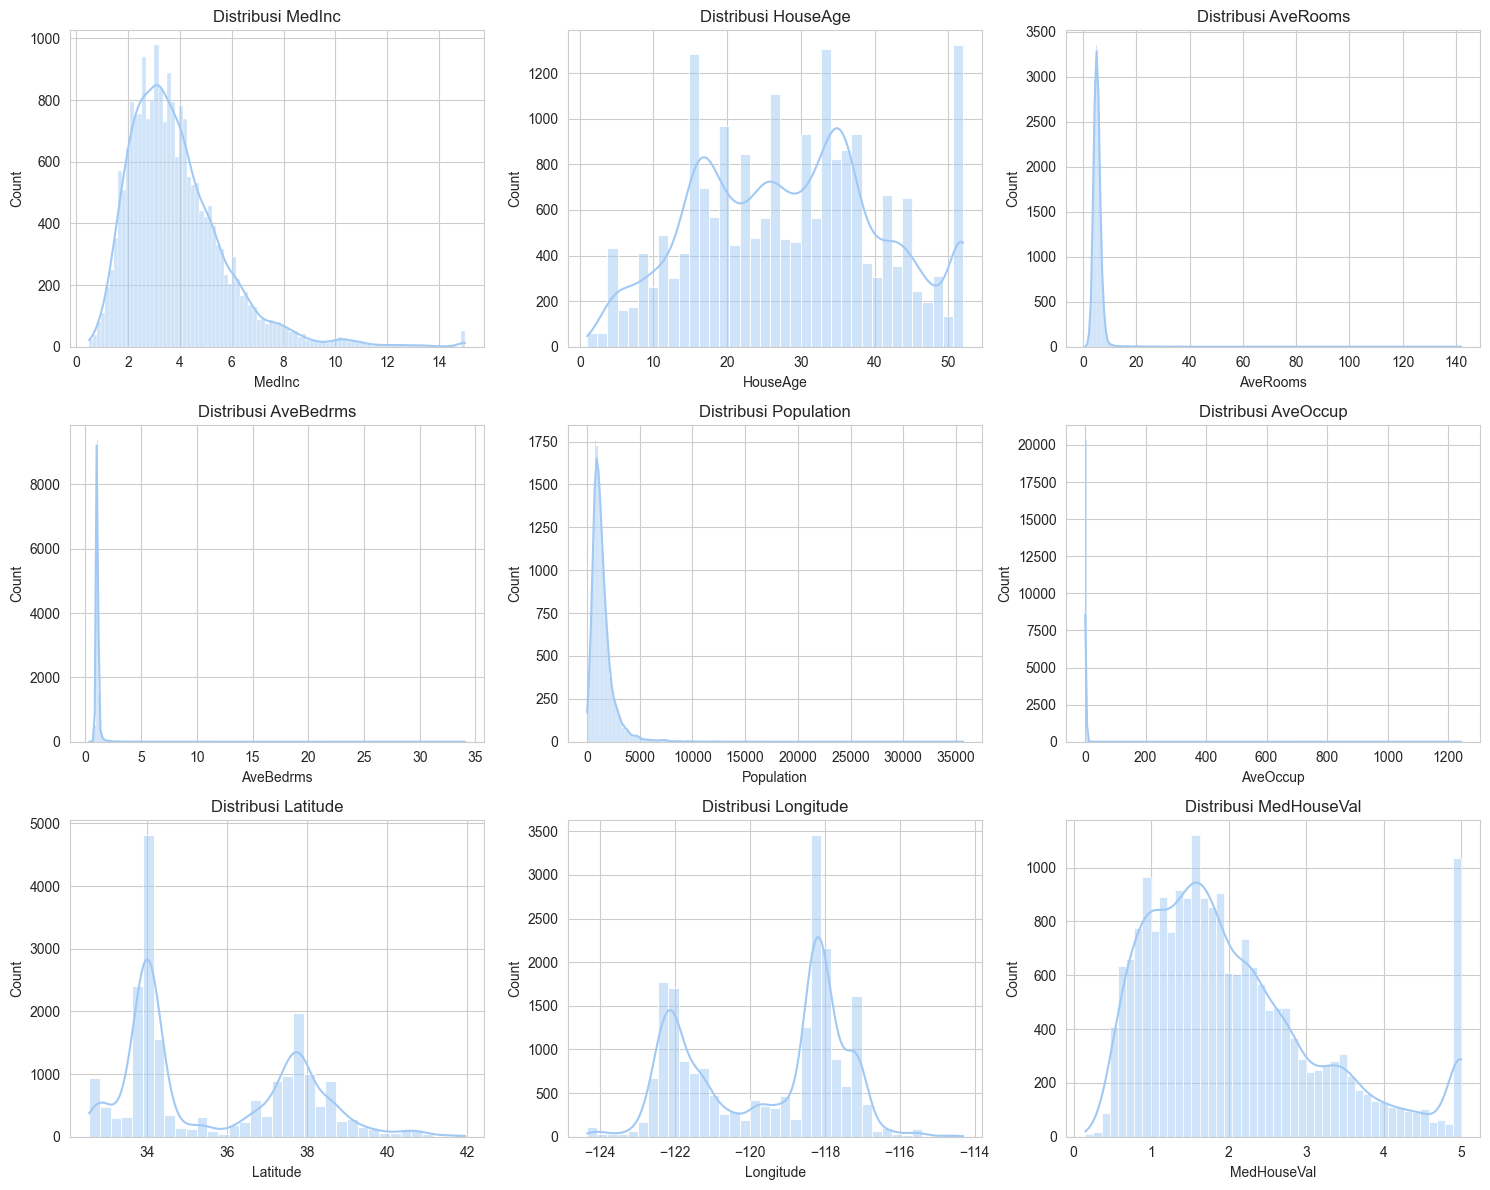

In [ ]:
# Style biar bagus
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Load data
data = fetch_california_housing(as_frame=True)
df = data.frame

# Ambil semua kolom numerik
columns = df.columns

# Buat subplot
ncols = 3
nrows = (len(columns) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

# Loop histogram + KDE
for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')

# Sembunyikan plot kosong
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Berikut adalah penjelasan tentang variabel-variabel dalam dataset tersebut:
- **MedInc (Median Income)** - Pendapatan median per blok (dalam puluhan ribu dolar). Ini adalah rata-rata dari pendapatan rumah tangga di daerah tertentu.
- **HouseAge (House Age)** - Usia rata-rata rumah-rumah di blok tersebut (dalam tahun).
- **AveRooms (Average Rooms)** - Rata-rata jumlah ruangan di rumah-rumah di blok tersebut.
- **AveBedrms (Average Bedrooms)** - Rata-rata jumlah kamar tidur di rumah-rumah di blok tersebut.
- **Population** - Jumlah penduduk yang tinggal di blok tersebut.
- **AveOccup (Average Occupancy)** - Jumlah rata-rata penghuni per rumah di blok tersebut.
- **Latitude** - Garis lintang lokasi blok (dalam derajat).
- **Longitude** - Garis bujur lokasi blok (dalam derajat).
- **MedHouseVal (Median House Value)** - Nilai median rumah di blok tersebut (dalam ratusan ribu dolar).

**Interpretasi Histogram + KDE**                       
**KDE (Kernel Density Estimation)** adalah metode untuk menampilkan distribusi data dalam bentuk kurva halus sehingga memudahkan dalam melihat pola sebaran data dibandingkan histogram biasa. 

**1. MedInc (Median Income)**                                    
Distribusi cenderung miring ke kanan (right-skewed). Mayoritas nilai berada di rentang rendah hingga sedang, dengan beberapa nilai tinggi sebagai outlier.

**2. HouseAge (Usia Rumah)**                                  
Distribusi relatif merata, namun terdapat penumpukan nilai pada usia maksimum. Hal ini menunjukkan adanya pembatasan data pada nilai tertentu.

**3. AveRooms (Rata-rata Ruangan)**                                  
Distribusi sangat miring ke kanan dengan outlier ekstrem. Sebagian besar rumah memiliki jumlah ruangan normal, tetapi terdapat nilai yang sangat tinggi dan tidak wajar.

**4. AveBedrms (Rata-rata Kamar Tidur)**                                    
Sebagian besar data terkonsentrasi pada nilai rendah. Namun, terdapat beberapa outlier yang cukup jauh dari distribusi utama.

**5. Population (Populasi)**                                          
Distribusi menunjukkan pola right-skewed. Mayoritas wilayah memiliki populasi kecil hingga sedang, dengan beberapa wilayah berpopulasi sangat tinggi.

**6. AveOccup (Rata-rata Hunian)**                                  
Distribusi sangat tidak normal dan memiliki outlier ekstrem. Nilai yang sangat tinggi kemungkinan merupakan anomali atau kesalahan data.

**7. Latitude (Lintang)**                                                
Distribusi menunjukkan dua puncak (bimodal). Hal ini menandakan data terkonsentrasi pada dua wilayah geografis tertentu.

**8. Longitude (Bujur)**                                               
Distribusi juga bersifat bimodal. Ini menunjukkan adanya dua area utama dalam persebaran lokasi data.

**9. MedHouseVal (Harga Rumah)**                                         
Distribusi miring ke kanan. Sebagian besar rumah memiliki harga rendah hingga sedang, dengan beberapa rumah bernilai tinggi sebagai outlier.

**Kesimpulan**                                           
Sebagian besar variabel memiliki distribusi tidak normal dan cenderung miring ke kanan. Selain itu, terdapat beberapa outlier terutama pada AveRooms dan AveOccup yang perlu diperhatikan sebelum analisis lanjutan.

---

### **SOAL 3** ###                              
Tampilkan korelasi antar variabel numerik dalam dataset California Housing. Identifikasi variabel mana yang memiliki korelasi tertinggi dan terendah, dan jelaskan interpretasinya. 

### **Visualisasi Pairplot** ###

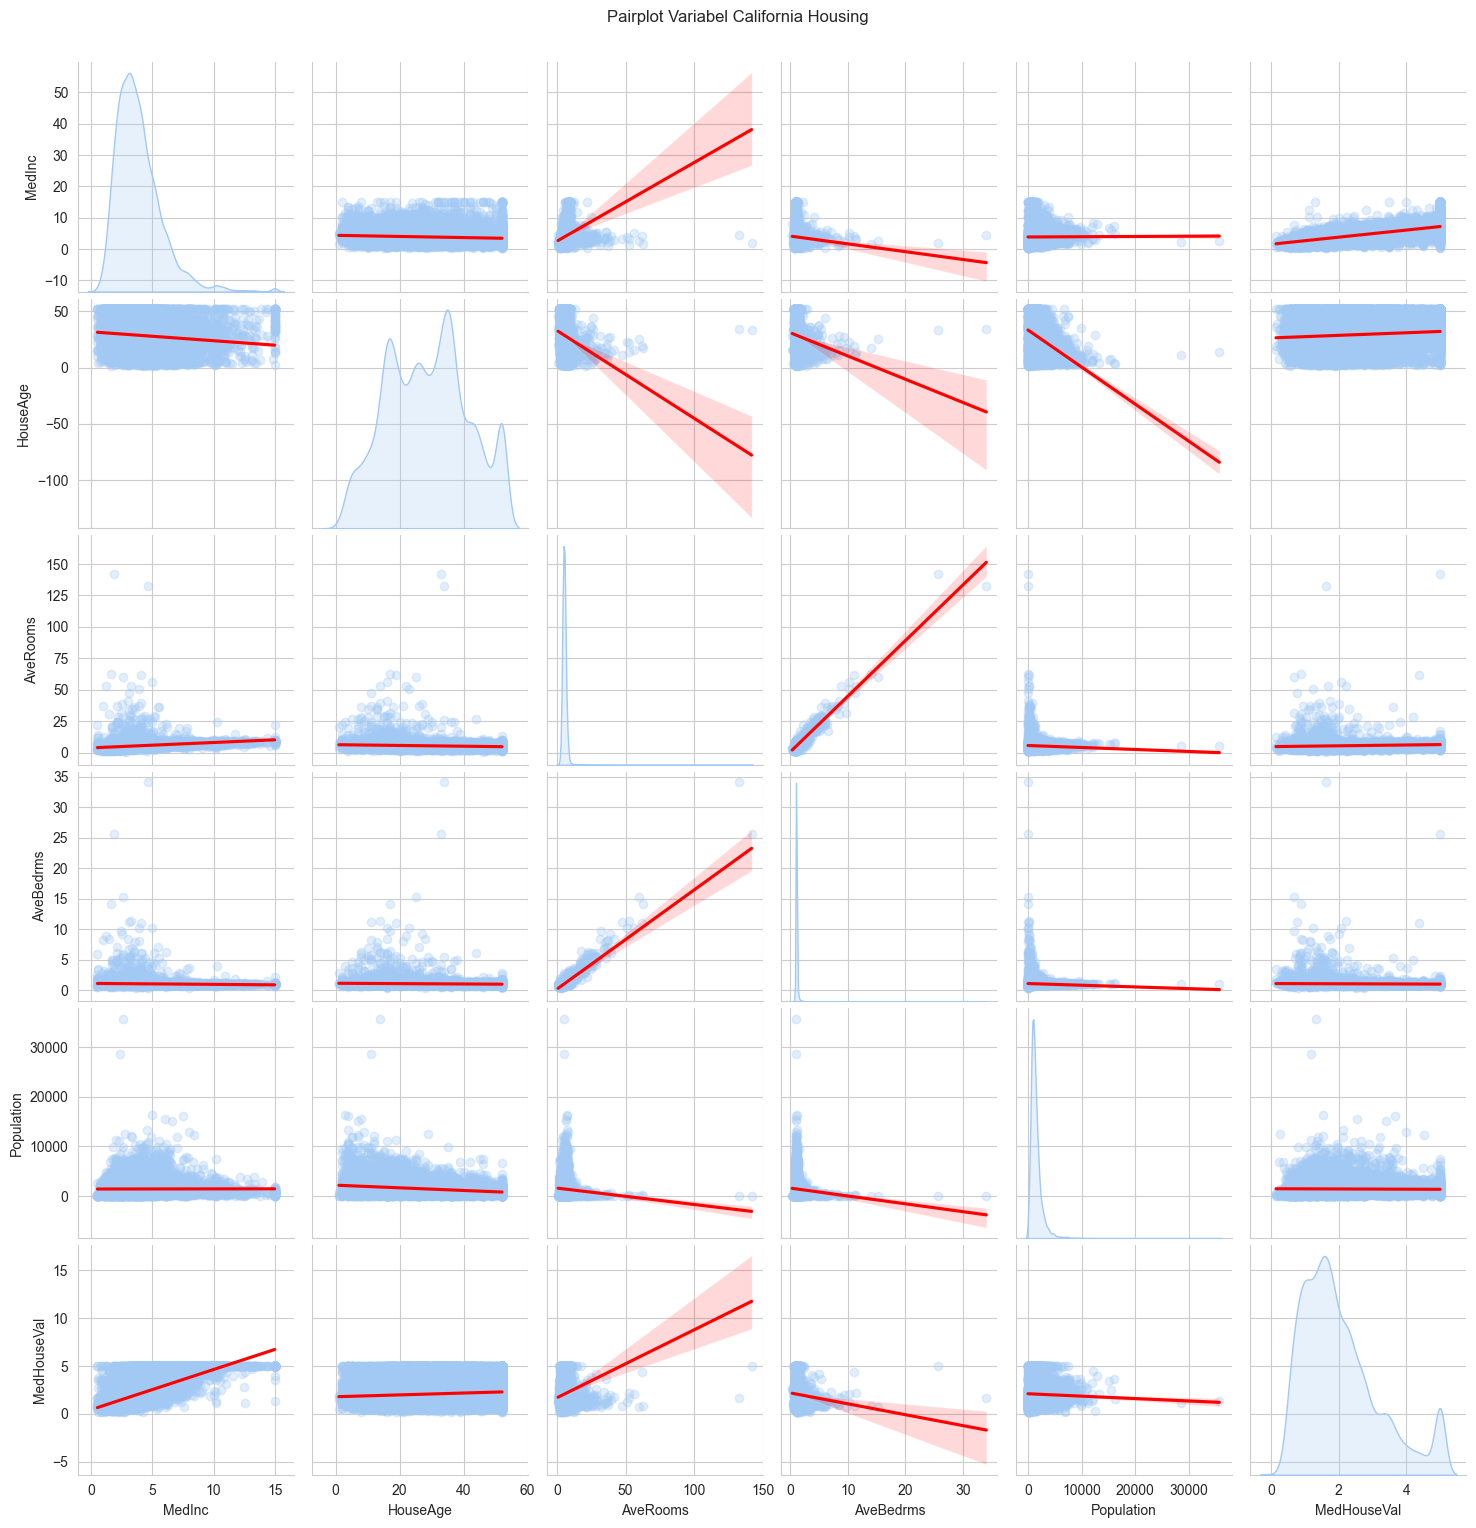

In [ ]:
# Load data
data = fetch_california_housing(as_frame=True)
df = data.frame

# Pilih variabel (biar ga terlalu penuh)
kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'MedHouseVal']

# Pairplot
sns.pairplot(
    df[kolom],
    kind='reg',          # scatter + garis regresi
    diag_kind='kde',     # diagonal pakai KDE
    plot_kws={
        'scatter_kws': {'alpha': 0.3},  # biar ga terlalu padat
        'line_kws': {'color': 'red'}
    }
)

plt.suptitle("Pairplot Variabel California Housing", y=1.02)
plt.show()

### **Penjelasan** ###                                        
Pairplot adalah grafik yang digunakan untuk melihat hubungan antar data dengan cara yang sederhana. Setiap kotak menunjukkan hubungan antara dua variabel dalam bentuk titik-titik (scatter plot).

Jika titik-titik membentuk pola naik, berarti hubungan kedua variabel tersebut positif. Jika menurun, berarti hubungannya negatif. Sedangkan jika titik-titik menyebar tanpa pola, berarti tidak ada hubungan yang jelas.

Selain itu, pada bagian diagonal terdapat grafik yang menunjukkan bagaimana sebaran data dari masing-masing variabel.

In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# Load data
data = fetch_california_housing(as_frame=True)
df = data.frame

# (Opsional) drop latitude & longitude
df = df.drop(columns=['Latitude', 'Longitude'])

# Hitung korelasi
corr_matrix = df.corr()

# Ambil pasangan unik (tanpa duplikat & diagonal)
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

# Rename kolom
corr_pairs.columns = ['Variabel 1', 'Variabel 2', 'Korelasi']

# Urutkan dari terbesar ke terkecil (berdasarkan absolut)
corr_pairs['Abs'] = corr_pairs['Korelasi'].abs()
corr_pairs = corr_pairs.sort_values(by='Abs', ascending=False).drop(columns='Abs')

corr_pairs['Peringkat'] = range(1, len(corr_pairs) + 1)
corr_pairs = corr_pairs[['Peringkat', 'Variabel 1', 'Variabel 2', 'Korelasi']]

print(corr_pairs.round(4))
corr_pairs.head(10)

    Peringkat   Variabel 1   Variabel 2  Korelasi
17          1     AveRooms    AveBedrms    0.8476
6           2       MedInc  MedHouseVal    0.6881
2           3       MedInc     AveRooms    0.3269
11          4     HouseAge   Population   -0.2962
9           5     HouseAge     AveRooms   -0.1533
20          6     AveRooms  MedHouseVal    0.1519
1           7       MedInc     HouseAge   -0.1190
13          8     HouseAge  MedHouseVal    0.1056
10          9     HouseAge    AveBedrms   -0.0777
18         10     AveRooms   Population   -0.0722
33         11   Population     AveOccup    0.0699
25         12    AveBedrms   Population   -0.0662
3          13       MedInc    AveBedrms   -0.0620
27         14    AveBedrms  MedHouseVal   -0.0467
34         15   Population  MedHouseVal   -0.0246
41         16     AveOccup  MedHouseVal   -0.0237
5          17       MedInc     AveOccup    0.0188
12         18     HouseAge     AveOccup    0.0132
26         19    AveBedrms     AveOccup   -0.0062


,Peringkat,Variabel 1,Variabel 2,Korelasi
17,1,AveRooms,AveBedrms,0.847621
6,2,MedInc,MedHouseVal,0.688075
2,3,MedInc,AveRooms,0.326895
11,4,HouseAge,Population,-0.296244
9,5,HouseAge,AveRooms,-0.153277
20,6,AveRooms,MedHouseVal,0.151948
1,7,MedInc,HouseAge,-0.119034
13,8,HouseAge,MedHouseVal,0.105623
10,9,HouseAge,AveBedrms,-0.077747
18,10,AveRooms,Population,-0.072213


### **Visualisasi Heatmap** ###

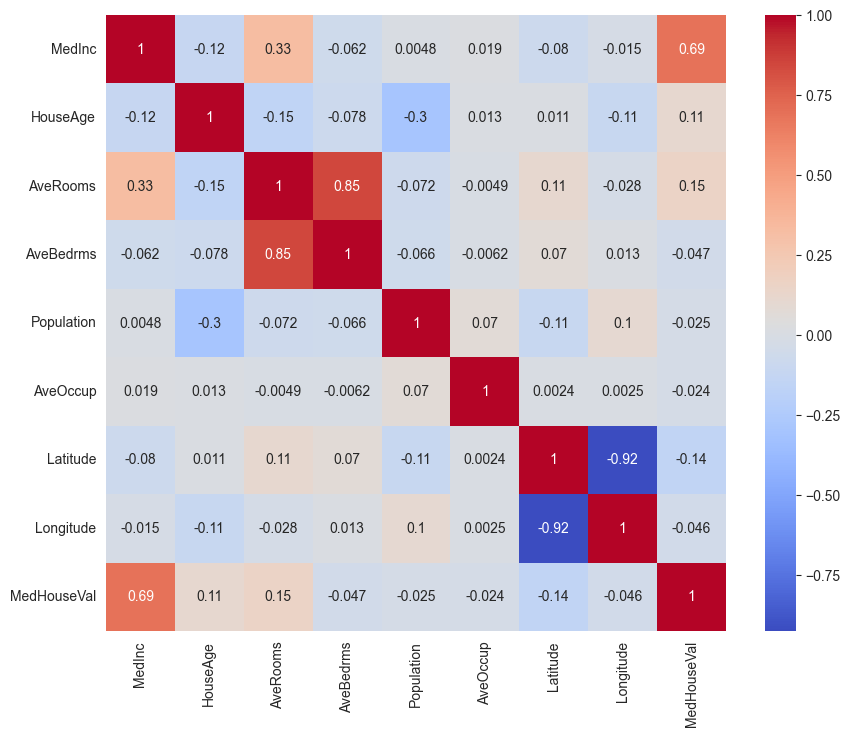

In [20]:
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### **Interpretasi Korelasi** ###

Berdasarkan hasil perhitungan korelasi, terlihat bahwa hubungan paling kuat terdapat pada variabel **AveRooms dan AveBedrms**, yang menunjukkan korelasi positif sangat tinggi. Hal ini menunjukkan bahwa semakin banyak jumlah ruangan, maka jumlah kamar tidur juga cenderung meningkat, sehingga kedua variabel ini memiliki hubungan yang sangat erat.

Selanjutnya, variabel **MedInc dan MedHouseVal** juga memiliki korelasi positif yang kuat. Hal ini berarti bahwa semakin tinggi pendapatan rata-rata suatu wilayah, maka harga rumah di wilayah tersebut juga cenderung lebih tinggi.

Beberapa variabel lain seperti **MedInc dengan AveRooms** menunjukkan hubungan sedang, yang berarti terdapat pengaruh namun tidak terlalu kuat.

Di sisi lain, terdapat hubungan negatif seperti pada **HouseAge dengan Population**, yang menunjukkan bahwa wilayah dengan rumah yang lebih tua cenderung memiliki populasi yang lebih rendah.

Sementara itu, sebagian besar pasangan variabel lainnya memiliki korelasi yang lemah hingga sangat lemah, sehingga hubungan antar variabel tersebut tidak terlalu signifikan.

Korelasi terendah terdapat pada **MedInc dan Population**, yang menunjukkan hampir tidak adanya hubungan antara pendapatan dan jumlah populasi dalam dataset ini.

---

### **SOAL 4** ###                  
Lakukan Analisis Regresi Berganda dan gunakan variabel MedInc sebagai variabel dependen. Berikan penjelasan mengenai nilai R-squared dan variabel mana yang paling berpengaruh terhadap variabel dependen.

In [16]:
import statsmodels.api as sm

# Variabel independen
X = df.drop(columns=['MedInc'])

# Variabel dependen
y = df['MedInc']

# Tambah konstanta
X = sm.add_constant(X)

# Model regresi
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     7257.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:29:50   Log-Likelihood:                -28717.
No. Observations:               20640   AIC:                         5.745e+04
Df Residuals:                   20631   BIC:                         5.752e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.5005      0.950     -4.739      

In [12]:
import statsmodels.api as sm

# Variabel independen (tanpa Population)
X = df.drop(columns=['MedInc', 'Population'])

# Variabel dependen
y = df['MedInc']

# Tambah konstanta
X = sm.add_constant(X)

# Model regresi
model = sm.OLS(y, X).fit()

# Ambil koefisien
coef = model.params

# Tampilkan persamaan
persamaan = f"y = {coef['const']:.4f}"

for var in coef.index[1:]:
    if coef[var] >= 0:
        persamaan += f" + {coef[var]:.4f}*{var}"
    else:
        persamaan += f" - {abs(coef[var]):.4f}*{var}"

print(persamaan)

y = 2.2813 - 0.0139*HouseAge + 0.7465*AveRooms - 3.4846*AveBedrms + 0.0057*AveOccup + 0.8400*MedHouseVal


### **Interpretasi** ###                         
Nilai **R-squared sebesar 0,73** menunjukkan bahwa sekitar 73% variasi pada variabel MedInc dapat dijelaskan oleh variabel-variabel independen dalam model. Hal ini berarti model regresi yang digunakan sudah cukup baik dalam menjelaskan hubungan antar variabel, meskipun masih terdapat sekitar 27% variasi yang dipengaruhi oleh faktor lain di luar model.

Berdasarkan nilai koefisien regresi, variabel **MedHouseVal dan AveRooms memiliki pengaruh positif yang cukup besar terhadap MedInc**, yang berarti **semakin tinggi nilai kedua variabel tersebut, maka pendapatan rata-rata juga cenderung meningkat**. Sementara itu, variabel **AveBedrms memiliki pengaruh negatif yang cukup signifikan**, yang menunjukkan bahwa peningkatan jumlah kamar tidur justru berkaitan dengan penurunan nilai MedInc.

Secara keseluruhan, model regresi ini mampu menggambarkan hubungan antar variabel dengan cukup baik, namun masih memerlukan perbaikan lebih lanjut, seperti penanganan outlier atau penambahan variabel lain agar hasil prediksi menjadi lebih akurat.

---

### **SOAL 5** ### 
**a. Jelaskan, apakah Anda dapat mengaplikasikan konsep Analisis Time Series pada data California Housing?**           
Data ini tidak dapat digunakan untuk analisis time series karena tidak memiliki komponen waktu. Data hanya menggambarkan kondisi pada satu periode (cross-sectional).

**b. Jelaskan konsep-konsep penting tren, musiman, dan noise dalam analisis time series!**
- **Tren** → kecenderungan naik atau turun dalam jangka panjang  
- **Musiman** → pola yang berulang dalam periode tertentu  
- **Noise** → variasi acak yang tidak beraturan  